# DroneTask — Pilot Viability Analysis (N = 10)

**Purpose.** Determine whether the task produces usable data before scaling to the full sample. Every section maps to a go/no-go criterion:

| Check | Question | Go criterion |
|---|---|---|
| **Completion & data integrity** | Do sessions finish and save? | ≥ 80 % completion, no systematic data loss |
| **Preload & technical health** | Does the asset pipeline work on Pavlovia? | ≤ 5 % preload failures, no trial-level display errors |
| **Prediction errors & learning** | Do participants track the drone? | Learning-rate slope > 0; α higher under high volatility |
| **Order memory above chance** | Is temporal-order memory measurable? | Group mean > 50 % (one-sample *t*) |
| **Distance-estimation variability** | Do participants use the scale? | SD > 0 within participants; non-degenerate distributions |
| **Segmentation-index computability** | Can we compute the cross-boundary contrast? | Index computable for ≥ 80 % of participant × condition cells |
| **Kalman-filter parameter recovery** | Does the model recover designed vol/stc? | Recovered volatility higher in high-vol blocks |
| **Directional plausibility** | Are effects in the predicted direction? | Segmentation cost larger under high volatility than high stochasticity |

> The final section collects these into a single summary table with pass/warn/fail status.

## Setup & data loading

In [15]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats, optimize

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook',
              palette='colorblind', font_scale=1.05)
pd.set_option('display.max_columns', 60)

CLEAN_DIR = os.path.join('..', 'data', 'clean')
VOL_ORDER = ['low', 'high']
VALENCE_ORDER = ['reward', 'loss']
REGIME_ORDER = ['lowVol_highStc', 'highVol_lowStc']
REGIME_LABELS = {'lowVol_highStc': 'Low vol / High stc',
                 'highVol_lowStc': 'High vol / Low stc'}

def regime_label(row):
    if row['vol_level'] == 'high' and row['stc_level'] == 'low':
        return 'highVol_lowStc'
    return 'lowVol_highStc'

def load_table(suffix):
    paths = sorted(glob.glob(os.path.join(CLEAN_DIR, f'*_{suffix}.csv')))
    if not paths:
        print(f'⚠ No *_{suffix}.csv files found in {os.path.abspath(CLEAN_DIR)}')
        return pd.DataFrame()
    frames = []
    for p in paths:
        stem = os.path.basename(p)[:-len(f'_{suffix}.csv')]
        parts = stem.rsplit('_', 1)
        pid = parts[0] if len(parts) == 2 else stem
        df = pd.read_csv(p); df.insert(0, 'pid', pid)
        frames.append(df)
    out = pd.concat(frames, ignore_index=True)
    print(f'  {suffix}: {len(paths)} files, {len(out)} rows, '
          f'{out["pid"].nunique()} participants')
    return out

print('Loading split tables from', os.path.abspath(CLEAN_DIR))
enc  = load_table('encoding')
mem  = load_table('memory')
meta = load_table('metadata')
prac = load_table('practice')

N = enc['pid'].nunique() if len(enc) else 0
print(f'\nParticipants: N = {N}')

# Memory labels must follow the canonical condition actually shown in each
# displayed block. Reattach them from encoding so this notebook also repairs
# files produced before the v3.2 runtime labeling fix.
condition_cols = [
    'design_idx', 'canonical_design_idx', 'condition_id',
    'true_vol_param', 'true_stc_param', 'vol_level', 'stc_level', 'valence'
]
if len(enc) and len(mem):
    available = [c for c in condition_cols if c in enc.columns]
    block_conditions = (enc.groupby(['pid', 'block'], as_index=False)[available]
                           .first())
    mem = (mem.drop(columns=[c for c in available if c in mem.columns])
              .merge(block_conditions, on=['pid', 'block'], how='left',
                     validate='many_to_one'))
    missing = mem['true_vol_param'].isna().sum() if 'true_vol_param' in mem else len(mem)
    print(f'Reattached memory condition labels from encoding; missing rows = {missing}')

# Attach factors
for df in (enc, mem):
    if len(df):
        df['regime']    = df.apply(regime_label, axis=1)
        df['vol_level'] = pd.Categorical(df['vol_level'], VOL_ORDER, ordered=True)
        df['valence']   = pd.Categorical(df['valence'], VALENCE_ORDER, ordered=True)
        df['regime']    = pd.Categorical(df['regime'], REGIME_ORDER, ordered=True)

Loading split tables from /Users/yizj/Desktop/Desktop - beaverjuly/InCogLab/DroneTask/data/clean
  encoding: 2 files, 400 rows, 2 participants
  memory: 2 files, 112 rows, 2 participants
  metadata: 2 files, 2 rows, 2 participants
  practice: 2 files, 26 rows, 2 participants

Participants: N = 2
Reattached memory condition labels from encoding; missing rows = 0


## Completion & data integrity

**Question.** Do participants finish the full session and save data without loss?

**Method.**
- Count sessions in metadata vs encoding vs memory tables
- Flag participants missing blocks or with unusually few trials
- Check for incomplete sessions (< 200 encoding trials, < 4 memory blocks)

**Go criterion.** ≥ 80 % of enrolled participants have complete data (200 encoding + 4 blocks of memory).

In [16]:
# Completion audit
completion = []
all_pids = set()
for df, name in [(meta,'meta'), (enc,'encoding'), (mem,'memory')]:
    if len(df): all_pids.update(df['pid'].unique())

for pid in sorted(all_pids):
    e = enc[enc['pid'] == pid] if len(enc) else pd.DataFrame()
    m = mem[mem['pid'] == pid] if len(mem) else pd.DataFrame()
    n_enc = len(e)
    n_blocks_enc = e['block'].nunique() if len(e) else 0
    n_mem = len(m)
    n_blocks_mem = m['block'].nunique() if len(m) else 0
    complete = (n_enc == 200) and (n_blocks_enc == 4) and (n_blocks_mem == 4)
    completion.append({
        'pid': pid, 'enc_trials': n_enc, 'enc_blocks': n_blocks_enc,
        'mem_trials': n_mem, 'mem_blocks': n_blocks_mem, 'complete': complete
    })

comp_df = pd.DataFrame(completion)
n_complete = comp_df['complete'].sum()
pct_complete = n_complete / len(comp_df) * 100 if len(comp_df) else 0
PASS_COMPLETION = pct_complete >= 80

print(f'Completion: {n_complete}/{len(comp_df)} ({pct_complete:.0f}%)')
print(f'→ {"✅ PASS" if PASS_COMPLETION else "❌ FAIL"}: criterion is ≥ 80%\n')
display(comp_df)

Completion: 2/2 (100%)
→ ✅ PASS: criterion is ≥ 80%



,pid,enc_trials,enc_blocks,mem_trials,mem_blocks,complete
0,1782031815436,200,4,56,4,True
1,1782114074962,200,4,56,4,True


## Preload & technical health

**Question.** Does the asset-loading pipeline work reliably on Pavlovia?

**Method.**
- Read `preload_loaded`, `preload_total`, `preload_failed` from metadata
- Compute per-session failure rate
- Flag sessions where > 5 % of assets failed

**Go criterion.** Median preload failure rate ≤ 5 %.

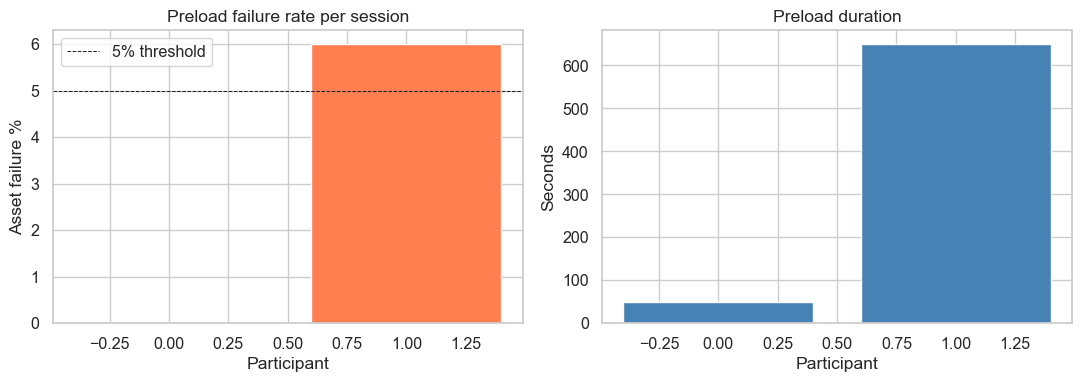

Median failure rate: 3.0%
→ ✅ PASS: criterion is ≤ 5%


,pid,preload_loaded,preload_total,preload_failed,preload_elapsed_ms,preload_mode,preload_fail_rate
0,1782031815436,200,200,0,48212,background,0.0
1,1782114074962,200,200,12,649588,background,6.0


In [17]:
if len(meta) and 'preload_loaded' in meta.columns:
    meta['preload_fail_rate'] = (meta['preload_failed'].fillna(0) /
                                  meta['preload_total'].fillna(1) * 100).round(1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].bar(range(len(meta)), meta['preload_fail_rate'], color='coral')
    axes[0].set_ylabel('Asset failure %'); axes[0].set_xlabel('Participant')
    axes[0].set_title('Preload failure rate per session')
    axes[0].axhline(5, color='k', ls='--', lw=.7, label='5% threshold')
    axes[0].legend()
    axes[1].bar(range(len(meta)), meta['preload_elapsed_ms'].fillna(0)/1000, color='steelblue')
    axes[1].set_ylabel('Seconds'); axes[1].set_xlabel('Participant')
    axes[1].set_title('Preload duration')
    plt.tight_layout(); plt.show()

    median_fail = meta['preload_fail_rate'].median()
    PASS_PRELOAD = median_fail <= 5
    print(f'Median failure rate: {median_fail:.1f}%')
    print(f'→ {"✅ PASS" if PASS_PRELOAD else "❌ FAIL"}: criterion is ≤ 5%')
    display(meta[['pid','preload_loaded','preload_total','preload_failed',
                  'preload_elapsed_ms','preload_mode','preload_fail_rate']])
else:
    PASS_PRELOAD = None
    print('⚠ Preload columns not found in metadata — skipping this check.')

## Prediction errors & learning

**Question.** Do participants track the latent drone position, and does their learning rate adapt to the volatility/stochasticity regime?

**Quantities derived from each trial.**

| Measure | Formula | Meaning |
|---|---|---|
| Outcome PE | bag − bucket | Experienced surprise (drives learning & boundary perception) |
| Tracking error | bucket − drone | How well participant infers the hidden state |
| Learning rate α | Slope of (bucket_{t+1} − bucket_t) on PE_t | Trial-wise belief-update gain |

**Normative prediction.** α should be *higher* under high volatility (changes are real) and *lower* under high stochasticity (PEs are noise). Recovering this dissociation validates that participants' learning differed between regimes — a prerequisite for the memory hypothesis.

**Go criterion.** Mean α > 0 in every condition; α significantly higher in high-vol than low-vol blocks.

In [18]:
# Derive PE signals
enc['pe_outcome']   = enc['bag_position'] - enc['bucket_position']
enc['abs_pe']       = enc['pe_outcome'].abs()
enc['track_err']    = enc['bucket_position'] - enc['drone_position']
enc['abs_track_err']= enc['track_err'].abs()

# Within-block z-scored PE (used later for boundary tagging)
enc['pe_z']         = (enc.groupby(['pid','block'], observed=True)['pe_outcome']
                          .transform(lambda x: (x - x.mean()) / (x.std(ddof=0) + 1e-9)))
enc['abs_pe_z']     = enc['pe_z'].abs()

# PE summary table
pe_tab = (enc.groupby(['regime','valence'], observed=True)
             [['abs_pe','abs_track_err']]
             .agg(['mean','std']).round(2))
display(pe_tab)

abs_pe       abs_track_err      
                         mean   std          mean   std
regime         valence                                 
lowVol_highStc reward    8.12  6.26          8.10  6.79
               loss      7.48  6.69          7.28  6.99
highVol_lowStc reward    6.62  5.96          5.08  5.63
               loss      6.66  5.47          5.33  4.56

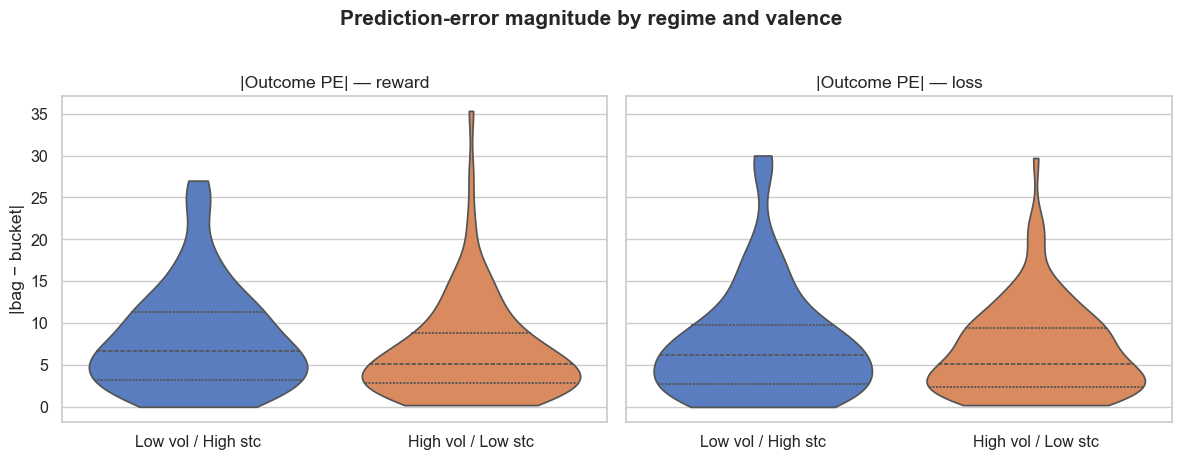

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, val in zip(axes, VALENCE_ORDER):
    sub = enc[enc['valence'] == val]
    sns.violinplot(data=sub, x='regime', y='abs_pe', order=REGIME_ORDER,
                   inner='quartile', ax=ax, cut=0, palette='muted')
    ax.set_xticklabels([REGIME_LABELS[r] for r in REGIME_ORDER])
    ax.set_title(f'|Outcome PE| — {val}')
    ax.set_ylabel('|bag − bucket|' if ax == axes[0] else '')
    ax.set_xlabel('')
plt.suptitle('Prediction-error magnitude by regime and valence', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

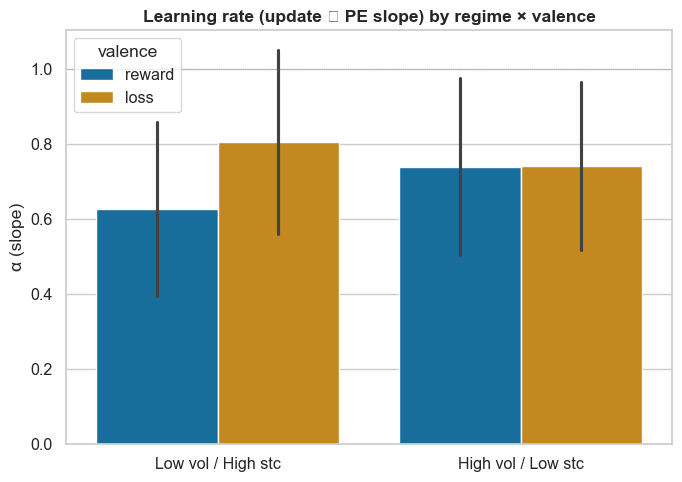

Overall mean α = 0.728  →  ✅ > 0
  reward: highVol α vs lowVol α — t(1)=20.36, p=0.031
  loss: highVol α vs lowVol α — t(1)=-3.09, p=0.199


In [20]:
# Learning rate: slope of update on PE, per participant × condition
def compute_lr(g):
    g = g.sort_values('trial')
    pe  = g['pe_outcome'].values[:-1]
    upd = np.diff(g['bucket_position'].values)
    ok  = np.isfinite(pe) & np.isfinite(upd)
    return np.polyfit(pe[ok], upd[ok], 1)[0] if ok.sum() >= 5 else np.nan

lr = (enc.groupby(['pid','valence','regime'], observed=True)
         .apply(compute_lr).reset_index(name='alpha'))

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=lr, x='regime', y='alpha', hue='valence',
            order=REGIME_ORDER, hue_order=VALENCE_ORDER, errorbar='se', ax=ax)
ax.set_xticklabels([REGIME_LABELS[r] for r in REGIME_ORDER])
ax.axhline(0, color='k', lw=.6); ax.axhline(1, color='grey', lw=.5, ls=':')
ax.set_title('Learning rate (update ∼ PE slope) by regime × valence', fontweight='bold')
ax.set_ylabel('α (slope)'); ax.set_xlabel('')
plt.tight_layout(); plt.show()

# Test: α > 0 overall, and α(highVol) > α(lowVol)
mean_alpha = lr['alpha'].mean()
PASS_LEARNING = mean_alpha > 0
print(f'Overall mean α = {mean_alpha:.3f}  →  {"✅ > 0" if PASS_LEARNING else "❌ ≤ 0"}')

if N >= 2:
    for val in VALENCE_ORDER:
        w = (lr[lr['valence']==val]
             .pivot_table(index='pid', columns='regime', values='alpha'))
        if {'highVol_lowStc','lowVol_highStc'}.issubset(w.columns):
            d = w.dropna()
            if len(d) >= 2:
                t, p = stats.ttest_rel(d['highVol_lowStc'], d['lowVol_highStc'])
                print(f'  {val}: highVol α vs lowVol α — t({len(d)-1})={t:.2f}, p={p:.3f}')

## Order memory: above-chance performance

**Question.** Can participants judge which of two items appeared earlier — i.e., is temporal-order memory measurable at all?

**Method.**
- `order_correct_bin` = 1 if participant chose the correct earlier item
- Chance = 50 % (binary forced choice)
- One-sample *t*-test against 0.5 on per-participant means

**Go criterion.** Group mean order accuracy significantly above 50 % (*p* < .10, one-tailed, given N = 10).

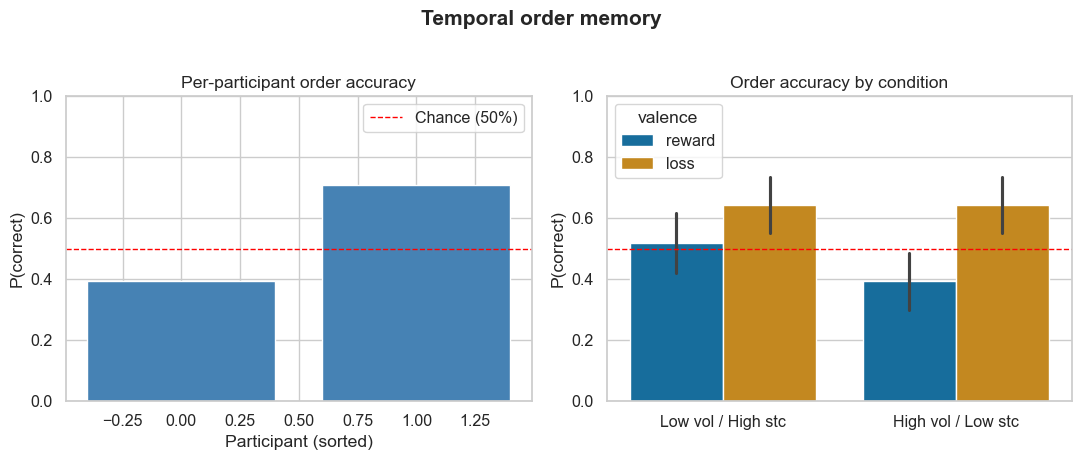

Mean = 0.551, t(1) = 0.32, p(one-tail) = 0.401
→ ⚠ WARN: criterion is p < .10


In [21]:
# Per-participant order accuracy
subj_order = (mem.groupby(['pid'], observed=True)['order_correct_bin']
                 .mean().reset_index(name='order_acc'))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
# Left: per-participant bar
axes[0].bar(range(len(subj_order)), subj_order['order_acc'].sort_values(),
            color='steelblue', edgecolor='white')
axes[0].axhline(.5, color='red', ls='--', lw=1, label='Chance (50%)')
axes[0].set_ylabel('P(correct)'); axes[0].set_xlabel('Participant (sorted)')
axes[0].set_title('Per-participant order accuracy')
axes[0].legend(); axes[0].set_ylim(0, 1)

# Right: by condition
sns.barplot(data=mem, x='regime', y='order_correct_bin', hue='valence',
            order=REGIME_ORDER, hue_order=VALENCE_ORDER, errorbar='se', ax=axes[1])
axes[1].set_xticklabels([REGIME_LABELS[r] for r in REGIME_ORDER])
axes[1].axhline(.5, color='red', ls='--', lw=1)
axes[1].set_ylabel('P(correct)'); axes[1].set_xlabel('')
axes[1].set_title('Order accuracy by condition')
axes[1].set_ylim(0, 1)
plt.suptitle('Temporal order memory', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# One-sample t against 0.5
if len(subj_order) >= 2:
    t, p2 = stats.ttest_1samp(subj_order['order_acc'], 0.5)
    p1 = p2 / 2 if t > 0 else 1 - p2 / 2  # one-tailed
    PASS_ORDER = p1 < 0.10
    print(f'Mean = {subj_order["order_acc"].mean():.3f}, '
          f't({len(subj_order)-1}) = {t:.2f}, p(one-tail) = {p1:.3f}')
    print(f'→ {"✅ PASS" if PASS_ORDER else "⚠ WARN"}: criterion is p < .10')
else:
    PASS_ORDER = None
    print('Need ≥ 2 participants for t-test.')

## Distance estimation: variability & bias

**Question.** Do participants use the distance-judgment scale meaningfully, or do they respond degenerately (always the same number)?

**Method.**
- Examine distribution of `distance_estimate` responses
- Within-participant SD of estimates (degenerate if ≈ 0)
- Signed bias = estimate − true distance, by condition
- "Boundary expansion" = bias is larger for cross-boundary pairs

**Go criterion.** Median within-participant SD > 0.5; distribution is non-degenerate.

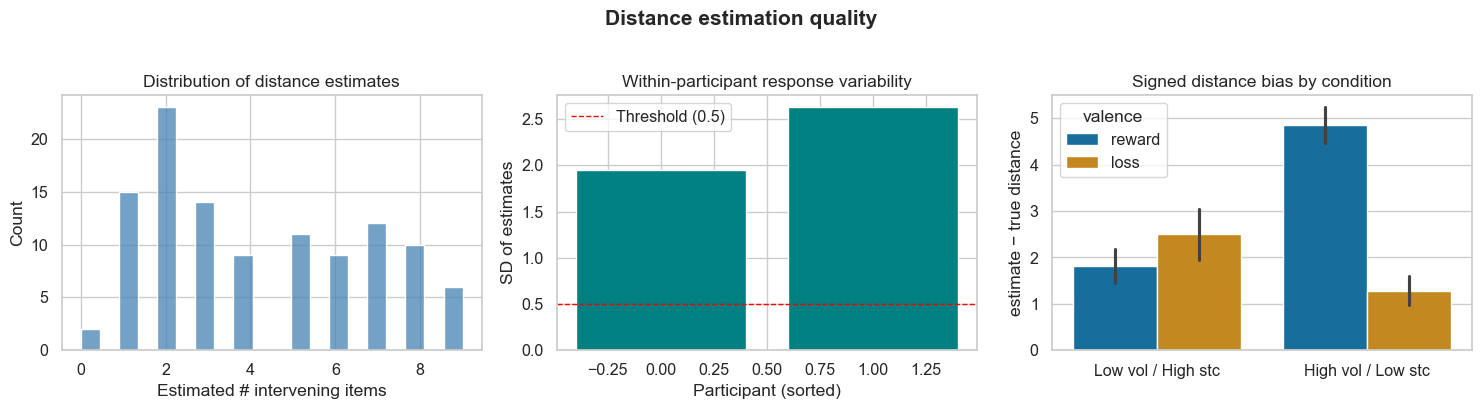

Median within-participant SD = 2.29
→ ✅ PASS: criterion is > 0.5


In [22]:
mem['dist_bias'] = mem['distance_estimate'] - mem['pair_true_distance']

# Within-participant SD of estimates
subj_dist_sd = (mem.groupby('pid', observed=True)['distance_estimate']
                   .std().reset_index(name='estimate_sd'))
median_sd = subj_dist_sd['estimate_sd'].median()
PASS_DIST = median_sd > 0.5

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Distribution of raw estimates
sns.histplot(data=mem, x='distance_estimate', bins=20, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of distance estimates')
axes[0].set_xlabel('Estimated # intervening items')

# Per-participant SD
axes[1].bar(range(len(subj_dist_sd)), subj_dist_sd['estimate_sd'].sort_values(),
            color='teal', edgecolor='white')
axes[1].axhline(0.5, color='red', ls='--', lw=1, label='Threshold (0.5)')
axes[1].set_ylabel('SD of estimates'); axes[1].set_xlabel('Participant (sorted)')
axes[1].set_title('Within-participant response variability')
axes[1].legend()

# Bias by condition
sns.barplot(data=mem, x='regime', y='dist_bias', hue='valence',
            order=REGIME_ORDER, hue_order=VALENCE_ORDER, errorbar='se', ax=axes[2])
axes[2].set_xticklabels([REGIME_LABELS[r] for r in REGIME_ORDER])
axes[2].axhline(0, color='k', lw=.6)
axes[2].set_title('Signed distance bias by condition')
axes[2].set_ylabel('estimate − true distance'); axes[2].set_xlabel('')

plt.suptitle('Distance estimation quality', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
print(f'Median within-participant SD = {median_sd:.2f}')
print(f'→ {"✅ PASS" if PASS_DIST else "❌ FAIL"}: criterion is > 0.5')

## Segmentation indices: computability

**Question.** Can we compute the cross-boundary vs within-event contrast for each participant × condition?

**Method.**
- Tag each encoding trial as a PE boundary (`|PE z| ≥ 1.0`)
- For each memory pair, find whether the spanned encoding interval contains a boundary
- Compute segmentation index = metric(cross-boundary) − metric(within-event) for:
  - **Order accuracy** (expected: negative → cross-boundary hurts order memory)
  - **Distance bias** (expected: positive → cross-boundary expands perceived distance)
- Count how many participant × regime × valence cells are computable (have both cross and within pairs)

**Go criterion.** Segmentation index computable for ≥ 80 % of cells.

In [23]:
# Tag encoding boundaries
BOUNDARY_Z = 1.0
enc['is_boundary'] = (enc['abs_pe_z'] >= BOUNDARY_Z).astype(int)

# For each memory pair: max |PE z| and boundary count in the spanned interval
def span_features(row, eblk):
    lo, hi = sorted([row['trial1_index'], row['trial2_index']])
    seg = eblk[(eblk['trial'] >= lo) & (eblk['trial'] <= hi)]
    if len(seg) == 0:
        return pd.Series({'span_max_pe_z': np.nan, 'span_n_bound': np.nan,
                          'span_mean_abs_pe': np.nan})
    return pd.Series({'span_max_pe_z': seg['abs_pe_z'].max(),
                      'span_n_bound':  seg['is_boundary'].sum(),
                      'span_mean_abs_pe': seg['abs_pe'].mean()})

feats = []
for (pid, blk), mblk in mem.groupby(['pid','block'], observed=True):
    eblk = enc[(enc['pid']==pid) & (enc['block']==blk)]
    f = mblk.apply(lambda r: span_features(r, eblk), axis=1)
    f.index = mblk.index
    feats.append(f)
mem = mem.join(pd.concat(feats)) if feats else mem
mem['spans_boundary'] = (mem['span_n_bound'] >= 1).astype('Int64')
mem['bnd_label'] = mem['spans_boundary'].map({0: 'within', 1: 'cross'})

# Segmentation index computation
def seg_index(df, metric, sign=1):
    agg = (df.dropna(subset=['spans_boundary', metric])
              .groupby(['pid','valence','regime','spans_boundary'], observed=True)[metric]
              .mean().reset_index())
    wide = agg.pivot_table(index=['pid','valence','regime'],
                           columns='spans_boundary', values=metric)
    if not {0,1}.issubset(wide.columns):
        return pd.DataFrame()
    wide['seg_index'] = sign * (wide[1] - wide[0])
    return wide.reset_index()[['pid','valence','regime','seg_index']]

seg_order = seg_index(mem, 'order_correct_bin', sign=-1)
seg_dist  = seg_index(mem, 'dist_bias',         sign=+1)

# Count computable cells
total_cells = N * 2 * 2  # pid × 2 regimes × 2 valences (if fully crossed)
n_computable_order = len(seg_order.dropna(subset=['seg_index']))
n_computable_dist  = len(seg_dist.dropna(subset=['seg_index']))
pct_order = n_computable_order / total_cells * 100 if total_cells else 0
pct_dist  = n_computable_dist  / total_cells * 100 if total_cells else 0
PASS_SEG = min(pct_order, pct_dist) >= 80

print(f'Computable cells: order = {n_computable_order}/{total_cells} ({pct_order:.0f}%), '
      f'distance = {n_computable_dist}/{total_cells} ({pct_dist:.0f}%)')
print(f'→ {"✅ PASS" if PASS_SEG else "⚠ WARN"}: criterion is ≥ 80%')

# Boundary rate by condition
print('\nBoundary rate (|PE z| ≥ 1.0) by condition:')
print(enc.groupby(['regime','valence'], observed=True)['is_boundary'].mean().round(3).unstack())
print(f'\nMemory pairs spanning ≥1 boundary: '
      f'{(mem["spans_boundary"]==1).sum()}/{len(mem)} '
      f'({(mem["spans_boundary"]==1).mean()*100:.0f}%)')

Computable cells: order = 8/8 (100%), distance = 8/8 (100%)
→ ✅ PASS: criterion is ≥ 80%

Boundary rate (|PE z| ≥ 1.0) by condition:
valence         reward  loss
regime                      
lowVol_highStc    0.31  0.26
highVol_lowStc    0.26  0.29

Memory pairs spanning ≥1 boundary: 68/112 (61%)


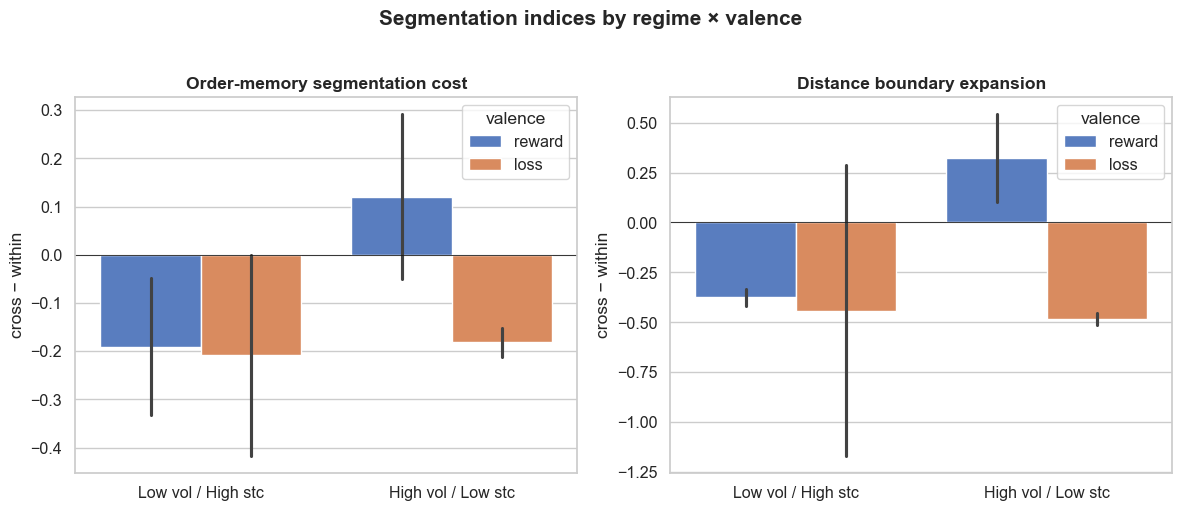

In [24]:
# Visualise segmentation indices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, seg, title in [(axes[0], seg_order, 'Order-memory segmentation cost'),
                       (axes[1], seg_dist,  'Distance boundary expansion')]:
    if len(seg):
        sns.barplot(data=seg, x='regime', y='seg_index', hue='valence',
                    order=REGIME_ORDER, hue_order=VALENCE_ORDER,
                    errorbar='se', ax=ax, palette='muted')
        ax.set_xticklabels([REGIME_LABELS[r] for r in REGIME_ORDER])
    ax.axhline(0, color='k', lw=.6)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('cross − within'); ax.set_xlabel('')
plt.suptitle('Segmentation indices by regime × valence', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## Kalman-filter parameter recovery

**Question.** Can we recover the designed volatility and stochasticity parameters from participants' tracking behaviour?

**Model.** A Kalman filter models the participant as an ideal observer with:
- **Process noise** $v$ (volatility): how much the latent state (drone) is expected to change between trials
- **Observation noise** $s$ (stochasticity): how spread the observed outcome (bag) is around the latent state
- **Motor noise** $m$: irreducible imprecision in the participant's bucket placement

The **Kalman gain** (learning rate) at each trial is:

$$K_t = \frac{P_{t|t-1}}{P_{t|t-1} + s}$$

We fit $(v, s, m)$ per participant × block by maximising the likelihood of observed bucket positions given the model's trial-by-trial predictions.

**Recovery check.** If the manipulation worked:
- Recovered $v$ should be **higher** in high-volatility blocks (designed vol = 49) than low-volatility blocks (designed vol = 4)
- Recovered $s$ should be **higher** in high-stochasticity blocks (designed stc = 64) than low-stochasticity blocks (designed stc = 16)

**Go criterion.** Recovered $v$ is significantly higher in high-vol than low-vol blocks (paired *t*, *p* < .10).

In [25]:
def kalman_nll(params, bag, bucket):
    """Negative log-likelihood under a Kalman filter with motor noise."""
    log_v, log_s, log_m = params
    v, s, m = np.exp(log_v), np.exp(log_s), np.exp(log_m)
    mu = bucket[0]
    P  = v + s
    nll = 0.0
    for t in range(1, len(bag)):
        P_pred = P + v
        K      = P_pred / (P_pred + s)
        pe     = bag[t-1] - mu
        mu_new = mu + K * pe
        P      = (1 - K) * P_pred
        nll   += 0.5 * np.log(2 * np.pi * m) + 0.5 * (bucket[t] - mu_new)**2 / m
        mu     = mu_new
    return nll

kf_results = []
for (pid, blk), g in enc.groupby(['pid','block'], observed=True):
    g = g.sort_values('trial')
    bag = g['bag_position'].values
    bkt = g['bucket_position'].values
    if len(bag) < 10:
        continue
    res = optimize.minimize(kalman_nll, x0=[2., 2., 3.], args=(bag, bkt),
                            method='Nelder-Mead',
                            options={'maxiter': 5000, 'xatol': 1e-4})
    v_r, s_r, m_r = np.exp(res.x)
    kf_results.append({
        'pid': pid, 'block': blk,
        'vol_level': g['vol_level'].iloc[0], 'stc_level': g['stc_level'].iloc[0],
        'valence': g['valence'].iloc[0], 'regime': g['regime'].iloc[0],
        'vol_designed': g['true_vol_param'].iloc[0],
        'stc_designed': g['true_stc_param'].iloc[0],
        'vol_recovered': v_r, 'stc_recovered': s_r, 'motor_noise': m_r
    })
kf = pd.DataFrame(kf_results)
print(f'Fitted {len(kf)} participant × block Kalman models.')
display(kf.groupby(['vol_level','regime'], observed=True)
          [['vol_designed','vol_recovered','stc_designed','stc_recovered','motor_noise']]
          .mean().round(2))

Fitted 8 participant × block Kalman models.


,,vol_designed,vol_recovered,stc_designed,stc_recovered,motor_noise
vol_level,regime,,,,,
high,highVol_lowStc,49.0,21.66,16.0,12.11,33.97
low,lowVol_highStc,4.0,22.27,64.0,6.19,38.55


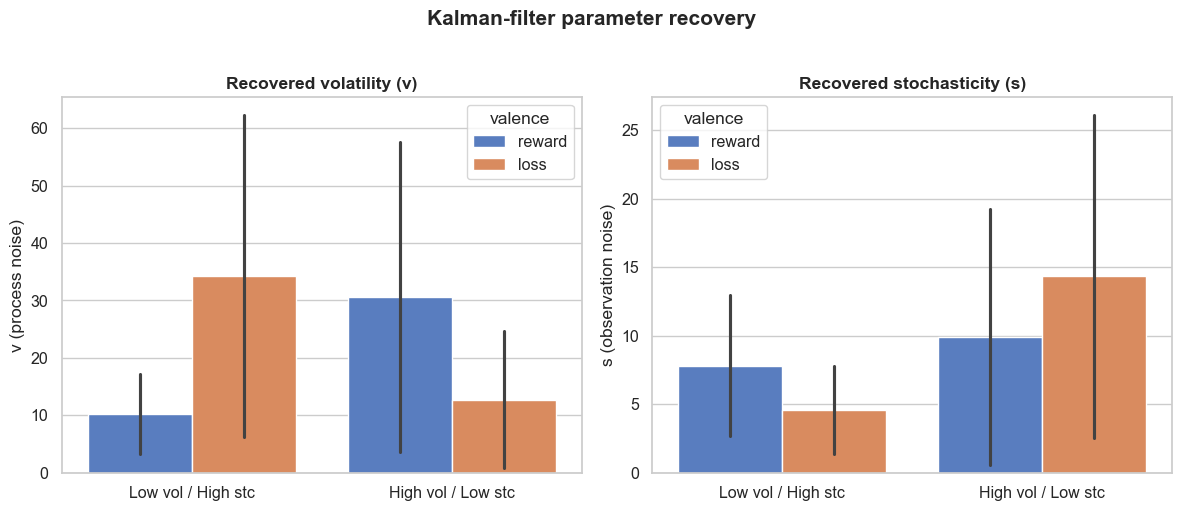

Recovered vol: high=21.7, low=22.3
Paired t(1) = -0.32, p = 0.803
→ ⚠ WARN: vol recovery in expected direction, p < .10


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Recovered volatility
sns.barplot(data=kf, x='regime', y='vol_recovered', hue='valence',
            order=REGIME_ORDER, hue_order=VALENCE_ORDER, errorbar='se',
            ax=axes[0], palette='muted')
axes[0].set_xticklabels([REGIME_LABELS[r] for r in REGIME_ORDER])
axes[0].set_title('Recovered volatility (v)', fontweight='bold')
axes[0].set_ylabel('v (process noise)'); axes[0].set_xlabel('')

# Recovered stochasticity
sns.barplot(data=kf, x='regime', y='stc_recovered', hue='valence',
            order=REGIME_ORDER, hue_order=VALENCE_ORDER, errorbar='se',
            ax=axes[1], palette='muted')
axes[1].set_xticklabels([REGIME_LABELS[r] for r in REGIME_ORDER])
axes[1].set_title('Recovered stochasticity (s)', fontweight='bold')
axes[1].set_ylabel('s (observation noise)'); axes[1].set_xlabel('')

plt.suptitle('Kalman-filter parameter recovery', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# Paired t: recovered vol in highVol > lowVol
if N >= 2:
    kf_subj = kf.groupby(['pid','vol_level'], observed=True)['vol_recovered'].mean().reset_index()
    w = kf_subj.pivot_table(index='pid', columns='vol_level', values='vol_recovered').dropna()
    if len(w) >= 2:
        t, p = stats.ttest_rel(w['high'], w['low'])
        PASS_KF = (t > 0) and (p < 0.10)
        print(f'Recovered vol: high={w["high"].mean():.1f}, low={w["low"].mean():.1f}')
        print(f'Paired t({len(w)-1}) = {t:.2f}, p = {p:.3f}')
        print(f'→ {"✅ PASS" if PASS_KF else "⚠ WARN"}: vol recovery in expected direction, p < .10')
    else:
        PASS_KF = None; print('Insufficient data for paired test.')
else:
    PASS_KF = None; print('Need ≥ 2 participants.')

## Directional plausibility of effects

**Question.** Are memory-segmentation effects in the hypothesised direction?

**Core hypothesis test.** Within a matched-PE band, the segmentation index (cross-boundary − within-event) should be **larger under high volatility** than under high stochasticity, because in volatile environments a large PE signals a genuine change-point (event boundary), while in stochastic environments a large PE is just noise.

**Method.**
- Restrict to the upper 2 terciles of spanned |PE| (matched-magnitude band)
- Compute per-participant segmentation index per regime
- Paired contrast: Δ seg-index = highVol − lowVol
- Effect size (Cohen's d) and direction

**Go criterion.** Effects are directionally positive (highVol seg > lowVol seg); not required to reach significance at N = 10.

In [27]:
# Matched-PE band: upper 2 terciles
if 'span_mean_abs_pe' in mem.columns:
    valid = mem.dropna(subset=['span_mean_abs_pe']).copy()
    valid['pe_band'] = pd.qcut(valid['span_mean_abs_pe'], 3,
                               labels=['low','mid','high'])
    matched = valid[valid['pe_band'].isin(['mid','high'])]
else:
    matched = mem.copy()

seg_order_m = seg_index(matched, 'order_correct_bin', sign=-1)
seg_dist_m  = seg_index(matched, 'dist_bias',         sign=+1)

results_table = []
for name, seg in [('Order seg cost', seg_order_m),
                  ('Distance expansion', seg_dist_m)]:
    if not len(seg):
        results_table.append({'Metric': name, 'Direction': '—', "Cohen's d": '—', 'p': '—'})
        continue
    wide = seg.pivot_table(index='pid', columns='regime', values='seg_index')
    if {'highVol_lowStc','lowVol_highStc'}.issubset(wide.columns):
        d = wide.dropna()
        if len(d) >= 2:
            diff = d['highVol_lowStc'] - d['lowVol_highStc']
            cohens_d = diff.mean() / (diff.std(ddof=1) + 1e-9)
            t, p = stats.ttest_rel(d['highVol_lowStc'], d['lowVol_highStc'])
            direction = '✅ correct' if diff.mean() > 0 else '⚠ reversed'
            results_table.append({'Metric': name, 'Direction': direction,
                                  "Cohen's d": f'{cohens_d:.2f}', 'p': f'{p:.3f}'})
        else:
            results_table.append({'Metric': name, 'Direction': '—', "Cohen's d": '—', 'p': '—'})
    else:
        results_table.append({'Metric': name, 'Direction': '—', "Cohen's d": '—', 'p': '—'})

dir_df = pd.DataFrame(results_table)
display(dir_df)
PASS_DIRECTION = any('correct' in str(r.get('Direction','')) for r in results_table)
print(f'→ {"✅ PASS" if PASS_DIRECTION else "⚠ WARN"}: at least one metric in expected direction')

,Metric,Direction,Cohen's d,p
0,Order seg cost,—,—,—
1,Distance expansion,—,—,—


→ ⚠ WARN: at least one metric in expected direction


## Pilot decision summary

Collects all go/no-go checks into a single table. A check is:
- **✅ Pass** if it meets the criterion
- **⚠ Warn** if directionally OK but below threshold (expected at N = 10)
- **❌ Fail** if it goes in the wrong direction or data is missing
- **—** if not evaluable (e.g., metadata columns missing)

In [28]:
summary = pd.DataFrame([
    {'Check': 'Completion rate',
     'Criterion': '≥ 80%',
     'Result': f'{pct_complete:.0f}%' if 'pct_complete' in dir() else '—',
     'Status': '✅' if (PASS_COMPLETION if 'PASS_COMPLETION' in dir() else False) else '❌'},
    {'Check': 'Preload failure rate',
     'Criterion': '≤ 5%',
     'Result': f'{median_fail:.1f}%' if 'median_fail' in dir() else '—',
     'Status': '✅' if (PASS_PRELOAD if PASS_PRELOAD is not None else False) else '—'},
    {'Check': 'Learning rate > 0',
     'Criterion': 'Mean α > 0',
     'Result': f'{mean_alpha:.3f}' if 'mean_alpha' in dir() else '—',
     'Status': '✅' if (PASS_LEARNING if 'PASS_LEARNING' in dir() else False) else '❌'},
    {'Check': 'Order memory > chance',
     'Criterion': 'p < .10 (one-tail)',
     'Result': f'{subj_order["order_acc"].mean():.3f}' if len(subj_order) else '—',
     'Status': '✅' if (PASS_ORDER if PASS_ORDER is not None else False) else '⚠'},
    {'Check': 'Distance variability',
     'Criterion': 'Median SD > 0.5',
     'Result': f'{median_sd:.2f}' if 'median_sd' in dir() else '—',
     'Status': '✅' if (PASS_DIST if 'PASS_DIST' in dir() else False) else '❌'},
    {'Check': 'Segmentation computable',
     'Criterion': '≥ 80% cells',
     'Result': f'{min(pct_order,pct_dist):.0f}%' if 'pct_order' in dir() else '—',
     'Status': '✅' if (PASS_SEG if 'PASS_SEG' in dir() else False) else '⚠'},
    {'Check': 'Kalman vol recovery',
     'Criterion': 'v(high) > v(low), p<.10',
     'Result': f't={t:.2f}' if 'PASS_KF' in dir() and PASS_KF is not None else '—',
     'Status': '✅' if (PASS_KF if 'PASS_KF' in dir() and PASS_KF is not None else False) else '⚠'},
    {'Check': 'Directional plausibility',
     'Criterion': 'Seg higher under highVol',
     'Result': dir_df.to_string(index=False)[:50] if 'dir_df' in dir() else '—',
     'Status': '✅' if (PASS_DIRECTION if 'PASS_DIRECTION' in dir() else False) else '⚠'},
])
display(summary[['Check','Criterion','Result','Status']])

n_pass = (summary['Status'] == '✅').sum()
n_fail = (summary['Status'] == '❌').sum()
print(f'\n{"="*50}')
print(f'  {n_pass} pass, {n_fail} fail, {len(summary)-n_pass-n_fail} warn/unknown')
if n_fail == 0:
    print('  → RECOMMENDATION: proceed to full data collection')
elif n_fail <= 2:
    print('  → RECOMMENDATION: investigate failures before scaling')
else:
    print('  → RECOMMENDATION: revise task design before scaling')

,Check,Criterion,Result,Status
0,Completion rate,≥ 80%,100%,✅
1,Preload failure rate,≤ 5%,3.0%,✅
2,Learning rate > 0,Mean α > 0,0.728,✅
3,Order memory > chance,p < .10 (one-tail),0.551,⚠
4,Distance variability,Median SD > 0.5,2.29,✅
5,Segmentation computable,≥ 80% cells,100%,✅
6,Kalman vol recovery,"v(high) > v(low), p<.10",t=-0.32,⚠
7,Directional plausibility,Seg higher under highVol,Metric Direction Cohen's d p\n ...,⚠



  5 pass, 0 fail, 3 warn/unknown
  → RECOMMENDATION: proceed to full data collection


## Caveats & notes

- **Vol and stc are anti-correlated by design** — every block is either high-vol/low-stc or low-vol/high-stc. The "regime" contrast conflates the two; matched-PE analysis is the best available control within this design. Acknowledge this in any writeup.
- **Boundary threshold is a researcher degree of freedom.** `|PE z| ≥ 1.0` is the default. Run sensitivity across 0.75–1.5 before drawing conclusions.
- **Kalman filter is a simplified ideal-observer model.** It assumes stationary parameters within a block and Gaussian noise. A hierarchical particle filter with change-point detection (e.g., Nassar et al. 2010) would be more principled for the volatile condition specifically.
- **N = 10 is insufficient for the directional test to reach significance.** The purpose here is only to check that effects are *directionally* consistent; significance will require the full planned sample.
- **Multiple comparisons.** Several tests are run. Pre-register the primary contrast (order-memory segmentation cost: highVol > highStc) and treat everything else as exploratory.